# Tier 0 — The Physics Backbone
### A differentiable two-resistance surrogate for surface-limited Si/Si epitaxy (RP-CVD)

**What this notebook builds.** A *cheap, analytic, differentiable* map

$$\theta \;=\;(T_s,\,p,\,\dot m\text{-like flow},\,p_{\mathrm{SiH_4}},\dots)\ \longmapsto\ G\ \text{(growth rate)}$$

assembled from first principles, with **no CFD-ACE+ run required** and **no GPU**. It is the *prior* that every later tier corrects, and the low-fidelity model $f_{\mathrm{LF}}$ that Tier 1 calibrates against ACE+.

**Three pieces, built in order:**

| Step | Module | Produces |
|---|---|---|
| **0b** | steady **surface-kinetics map** $\mathcal{R}$ | $G,\dot s_k$ from $(T_s,p_s)$ via a site balance |
| **0a** | **mass-transfer coefficient** $k_m$ | near-wall transport resistance from the flow |
| **0**  | **two-resistance coupling** | solve $k_m(c_\infty-c_s)=\mathcal{R}(c_s)$ for $c_s$, then $G(\theta)$ |

We deliberately build **0b first** (it is the heart and needs no flow), then **0a**, then couple. Everything is written in `jax` so `jax.grad` gives exact $\partial G/\partial\theta$ — the gradients you will hand to a gradient-based optimizer later.

> **Convention in this notebook:** *Markdown = the explicit step and the why.* *Code = the implementation you run.* Numbers in the kinetic ledger are **illustrative placeholders to be calibrated in Tier 1** — they are chosen to land in the right physical ballpark, not to be quantitatively final.


## Step 0 — Resources & environment (read once)

**Compute.** Tier 0 is tiny: scalar root-finds and a 1-D ODE. **A laptop CPU runs every cell in well under a second. Buy nothing, no GPU.** GPUs only matter later (Tier 2 operator learning; and your separate atomistics work). Here is the honest per-tier picture so you can plan spend:

| Tier | What runs | Compute you actually need |
|---|---|---|
| **0 (this)** | analytic backbone, `jax.grad` | **laptop CPU.** $0. |
| 1 gray-box | GP + Bayesian opt over ACE+ residuals | laptop CPU fine (≤ few hundred pts); ACE+ license = the real cost |
| 2 field operator | DeepONet / FNO training | **1 GPU** (RTX 4090 / A6000, or cloud A100 hrs). You likely already have AppMat GPU access |
| (atomistics) | DFT / MACE-NEB rate constants | CPU clusters + GPU for MLIPs (your other project) |

**Python libraries for Tier 0** (all free / open-source):

```bash
pip install jax jaxlib numpy scipy matplotlib jupyterlab
# optional, recommended later:
pip install optimistix      # ergonomic differentiable root/least-squares in JAX
pip install cantera         # real multi-species Surface-CHEMKIN mechanisms + thermo
```

**Libraries you will add per later tier** (install when you get there, not now):
`scikit-learn`, `gpytorch`+`botorch` (GP + multi-objective `qNEHVI` BO), `SALib` / `scipy.stats.qmc` (Sobol DoE), `torch`+`neuraloperator` (FNO) or `deepxde` (DeepONet/PINN), `numpyro` or `pymc` (Bayesian calibration / multi-fidelity fusion), `pandas` (the parameter ledger).

Run the next cell to confirm your Tier-0 stack is present.

In [1]:
import sys, importlib
need = ["jax","jaxlib","numpy","scipy","matplotlib"]
for m in need:
    try:
        importlib.import_module(m); print(f"  ok  {m}")
    except Exception as e:
        print(f"  MISSING  {m}  ->  pip install {m}")
print("python", sys.version.split()[0])

  ok  jax
  ok  jaxlib
  ok  numpy
  ok  scipy
  ok  matplotlib
python 3.12.3


## Step 1 — Constants, properties, and the parameter ledger

Two kinds of numbers live here, and you must keep them separate:

1. **Physical constants & material properties** — fixed, trustworthy (gas constant, Si density, site density).
2. **Kinetic parameters** (`PARAMS`) — *illustrative*, to be **calibrated in Tier 1**. We keep them in one dict so calibration later just overwrites this dict.

The site density for Si(100) is $\Gamma\approx6.78\times10^{18}\,\mathrm{m^{-2}}$; the molar volume of solid silicon is $\Omega_{\mathrm{Si}}=M_{\mathrm{Si}}/\rho_{\mathrm{Si}}$, which converts a molar Si flux into a film thickness rate.

**Unit discipline (the bug that bites everyone):** activation energies here are **per molecule** (in eV $\to$ J), so they must be paired with $k_B T$, *not* $R_uT$. Mixing them silently flattens your barriers.

In [2]:
import numpy as np
import jax, jax.numpy as jnp
from jax import grad
jax.config.update("jax_enable_x64", True)   # epitaxy rates need float64

# ---- physical constants (SI) ----
R_u = 8.314462618        # J/mol/K
k_B = 1.380649e-23       # J/K          (pair with per-MOLECULE energies)
N_A = 6.02214076e23      # 1/mol
eV  = 1.602176634e-19    # J

# ---- species / solid properties ----
M_SiH4 = 32.117e-3       # kg/mol
m_SiH4 = M_SiH4 / N_A    # kg (single molecule)
M_Si   = 28.0855e-3      # kg/mol
rho_Si = 2329.0          # kg/m^3
Omega_Si = M_Si / rho_Si # m^3/mol  -> turns mol-Si/m^2/s into m/s
Gamma  = 6.78e18 / N_A   # mol sites / m^2

# ---- ILLUSTRATIVE kinetic ledger (calibrate in Tier 1) ----
PARAMS = dict(
    s0     = 1.0e-2,   # reactive sticking prefactor (-)
    Ea_ads = 0.00*eV,  # SiH4 adsorption barrier on open sites (J/molecule)
    nu_des = 1.0e13,   # H2 desorption attempt frequency (1/s)
    Ea_des = 2.00*eV,  # H2 desorption barrier (J/molecule)  <- sets low-T apparent Ea
    beta   = 2.0,      # H2 molecules released per Si deposited (-)
)

def Pa(mtorr):  # convenience: millitorr -> Pascal
    return mtorr * 133.322e-3

print(f"Omega_Si = {Omega_Si:.3e} m^3/mol   Gamma = {Gamma:.3e} mol/m^2")

Omega_Si = 1.206e-05 m^3/mol   Gamma = 1.126e-05 mol/m^2


## Step 2 — Tier 0b: the steady surface-kinetics map $\mathcal{R}$

**Goal:** a function $\mathcal{R}:(T_s,p_s)\mapsto(G,\dot s)$. The chemistry is *stiff in time*, but we only ever need the **steady** state, which is an **algebraic** problem — so it is smooth and cheap.

### The minimal two-state mechanism
Surface sites are either **open** ($\ast$, coverage $\theta_\ast$) or **H-covered** ($\mathrm{H}^\ast$, coverage $\theta_H$), with $\theta_\ast+\theta_H=1$.

- **Dissociative adsorption / deposition** (needs two open sites):
$$R_{\mathrm{ads}} = k_{\mathrm{ads}}(T_s)\,p_{\mathrm{SiH_4}}\,\theta_\ast^2,\qquad
k_{\mathrm{ads}}=\frac{s_0\,e^{-E_{\mathrm{ads}}/k_BT}}{\sqrt{2\pi m_{\mathrm{SiH_4}}k_BT}\,N_A}.$$
The prefactor is the **Hertz–Knudsen collision flux** — adsorption can never exceed the rate molecules strike the surface.
- **$\mathrm{H_2}$ desorption** (frees sites, second order in H):
$$R_{\mathrm{des}} = k_{\mathrm{des}}(T_s)\,\theta_H^2,\qquad k_{\mathrm{des}}=\nu_{\mathrm{des}}\,\Gamma\,e^{-E_{\mathrm{des}}/k_BT}.$$

### Steady site balance
Each deposited Si ultimately releases $\beta$ H$_2$. At steady state H is produced (by deposition) as fast as it leaves (by desorption):
$$\boxed{\,k_{\mathrm{des}}\,\theta_H^2 \;=\; \beta\,k_{\mathrm{ads}}\,p_{\mathrm{SiH_4}}\,\theta_\ast^2\,}$$
With $\theta_\ast=1-\theta_H$ this is a quadratic, so $\theta_H/(1-\theta_H)=\sqrt{\beta k_{\mathrm{ads}}p/k_{\mathrm{des}}}\equiv r$, giving the **closed form** $\theta_H=r/(1+r)$. (We use the closed form for speed; Step 5.4 shows the general implicit-diff route for multi-species mechanisms with no closed form.)

The growth rate is then
$$G=\Omega_{\mathrm{Si}}\,R_{\mathrm{ads}}=\Omega_{\mathrm{Si}}\,k_{\mathrm{ads}}\,p_{\mathrm{SiH_4}}\,(1-\theta_H)^2.$$

In [3]:
def k_ads_eff(T, P):
    # R_ads = k_ads_eff * p_SiH4 * theta_open^2   [mol/m^2/s].
    return P['s0']*jnp.exp(-P['Ea_ads']/(k_B*T)) / (jnp.sqrt(2*jnp.pi*m_SiH4*k_B*T)*N_A)

def k_des_eff(T, P):
    # R_des = k_des_eff * theta_H^2            [mol H2/m^2/s].
    return P['nu_des']*Gamma*jnp.exp(-P['Ea_des']/(k_B*T))

def theta_H_steady(p_s, T_s, P):
    # Closed-form steady H coverage from the quadratic site balance.
    r = jnp.sqrt(P['beta']*k_ads_eff(T_s,P)*p_s / k_des_eff(T_s,P))
    return r/(1.0+r)

def surface_rate(p_s, T_s, P):
    # The map R: returns (G [m/s], R_ads [mol/m^2/s], theta_H).
    thH = theta_H_steady(p_s, T_s, P)
    R_ads = k_ads_eff(T_s,P)*p_s*(1.0-thH)**2
    return Omega_Si*R_ads, R_ads, thH

# quick smoke test at 900 K, 20 mtorr (surface-only, i.e. p_s = p_inf)
G,Rads,thH = surface_rate(Pa(20.0), 900.0, PARAMS)
print(f"@900K, 20mtorr (no transport):  G = {float(G)*1e9*60:6.2f} nm/min,  theta_H = {float(thH):.3f}")

@900K, 20mtorr (no transport):  G =  86.98 nm/min,  theta_H = 0.581


### Step 2.4 — Validate the map against known phenomenology
Before trusting $\mathcal{R}$, confirm it reproduces the two textbook limits of silane epitaxy:
1. **Arrhenius-with-rollover**: at low $T_s$, growth is **H-desorption-limited** ($G\propto e^{-E_{\mathrm{des}}/k_BT}$, steep); at high $T_s$ it saturates (supply-limited).
2. **Pressure dependence flips**: $p$-independent at low $T$ (sites H-saturated), linear in $p$ at high $T$.

If these plots don't show the rollover and the flip, your kinetics/units are wrong — this is your unit-test for the chemistry.

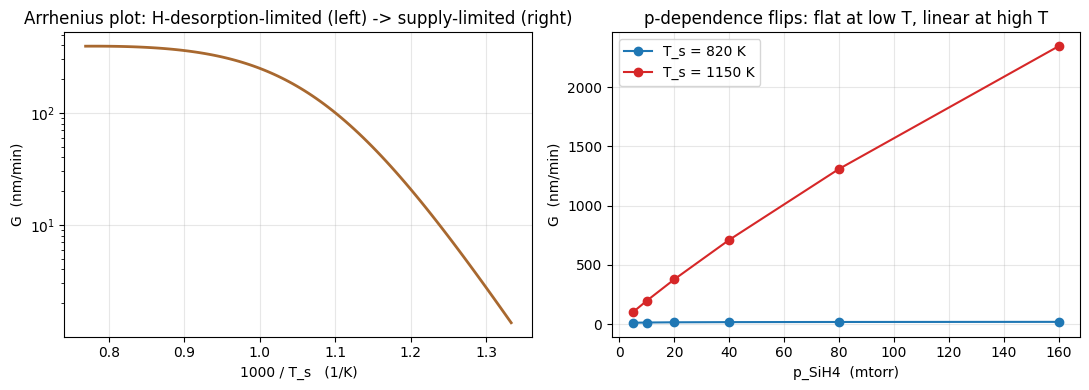

Low-T curve should be sub-linear (saturating); high-T curve should be a straight line through 0.


In [4]:
import matplotlib.pyplot as plt

T = np.linspace(750, 1300, 120)
G_T = np.array([float(surface_rate(Pa(20.0), float(t), PARAMS)[0]) for t in T])*1e9*60

fig, ax = plt.subplots(1,2, figsize=(11,4))
ax[0].semilogy(1000.0/T, G_T, lw=2, color="#A8682F")
ax[0].set_xlabel("1000 / T_s   (1/K)"); ax[0].set_ylabel("G  (nm/min)")
ax[0].set_title("Arrhenius plot: H-desorption-limited (left) -> supply-limited (right)")
ax[0].grid(alpha=.3)

for T0,c in [(820,"#1f77b4"),(1150,"#d62728")]:
    pm = np.array([5,10,20,40,80,160.])
    Gp = np.array([float(surface_rate(Pa(p), float(T0), PARAMS)[0]) for p in pm])*1e9*60
    ax[1].plot(pm, Gp, "-o", color=c, label=f"T_s = {T0} K")
ax[1].set_xlabel("p_SiH4  (mtorr)"); ax[1].set_ylabel("G  (nm/min)")
ax[1].set_title("p-dependence flips: flat at low T, linear at high T")
ax[1].legend(); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()
print("Low-T curve should be sub-linear (saturating); high-T curve should be a straight line through 0.")

## Step 3 — Tier 0a: the mass-transfer coefficient $k_m$

**Goal:** collapse all near-wall species transport into **one number** $k_m$ (per limiting species), so the reactor's flow enters the backbone only through $k_m$. We need $k_m$ *without* a full CFD solve.

### The stagnation-flow shortcut
Near a wafer in a showerhead/stagnation or rotating-disk reactor, the wall-normal velocity is approximately a **strained flow** $v(z)\approx -a\,z$, where $a$ is the **strain rate** ($a\sim v_{\rm in}/L$ for an impinging flow; $a\sim\Omega$ for a rotating disk). The steady passive-scalar balance $\rho v\,Y' = (\rho D\,Y')'$ then has an analytic solution. For a perfect-sink reference it gives a **closed-form** mass-transfer coefficient:
$$k_m=\frac{D}{\displaystyle\int_0^{L} e^{-a s^2/2D}\,ds}
=\frac{D}{\sqrt{\pi D/2a}\;\mathrm{erf}\!\big(L\sqrt{a/2D}\big)}
\ \xrightarrow[L\to\infty]{}\ \sqrt{\tfrac{2aD}{\pi}}.$$

**RP-CVD subtlety:** at reduced pressure $D$ is large, so the diffusion boundary layer $\sqrt{2D/a}$ can be *bigger than the gap $L$*. Then the semi-infinite form over-thins the layer and **underestimates** $k_m$ — you must keep the finite-gap `erf`. We'll see this explicitly.

In [5]:
from scipy.special import erf

def diffusivity(T, p_tot, D_ref=6.0e-5, T_ref=300.0, p_ref=101325.0):
    # Binary D(SiH4-H2), Chapman-Enskog scaling [m^2/s]. D_ref to be refined/calibrated.
    return D_ref*(T/T_ref)**1.75*(p_ref/p_tot)

def k_m_stagnation(a_strain, D, L):
    # Finite-gap closed-form stagnation mass-transfer coefficient [m/s].
    bl = jnp.sqrt(jnp.pi*D/(2*a_strain))
    return D / (bl*jax.scipy.special.erf(L*jnp.sqrt(a_strain/(2*D))))

def k_m_semiinf(a_strain, D):
    return jnp.sqrt(2*a_strain*D/jnp.pi)

# example operating point
T_s, p_tot, a, L = 900.0, Pa(10_000.), 10.0, 0.05
D = diffusivity(T_s, p_tot)
print(f"D(SiH4-H2) @900K,10Torr = {float(D):.3e} m^2/s")
print(f"diffusion BL  sqrt(2D/a) = {np.sqrt(2*float(D)/a)*100:.1f} cm   vs gap L = {L*100:.1f} cm")
print(f"k_m finite-gap = {float(k_m_stagnation(a,D,L)):.4f} m/s")
print(f"k_m semi-inf    = {float(k_m_semiinf(a,D)):.4f} m/s   (under-estimate when BL>gap)")

D(SiH4-H2) @900K,10Torr = 3.118e-02 m^2/s
diffusion BL  sqrt(2D/a) = 7.9 cm   vs gap L = 5.0 cm
k_m finite-gap = 0.7079 m/s
k_m semi-inf    = 0.4456 m/s   (under-estimate when BL>gap)


### Step 3.2 — Cross-check the closed form with a real BVP solve
Sanity is cheap: solve the same scalar transport as a two-point boundary-value problem with `scipy.solve_bvp` and confirm it reproduces the finite-gap closed form. (This is also the template for swapping in a *non-constant* velocity profile later — e.g. from a 1-D similarity momentum solution or an ACE+ line-out.)

In [6]:
from scipy.integrate import solve_bvp
a_, D_, L_, Yinf = 10.0, float(D), 0.05, 1.0

def ode(z,y): return np.vstack([y[1], -a_*z*y[1]/D_])   # D Y'' + a z Y' = 0
def bc(ya,yb): return np.array([ya[0]-0.0, yb[0]-Yinf]) # perfect sink at wall
zg = np.linspace(0,L_,200); g0 = np.zeros((2,zg.size)); g0[0]=Yinf*zg/L_
sol = solve_bvp(ode,bc,zg,g0,max_nodes=20000,tol=1e-8)

km_bvp = D_*sol.y[1][0]/Yinf
km_cf  = float(k_m_stagnation(a_,D_,L_))
print(f"k_m  BVP        = {km_bvp:.5f} m/s")
print(f"k_m  closed-form= {km_cf:.5f} m/s   (agree: {np.isclose(km_bvp,km_cf,rtol=1e-3)})")

k_m  BVP        = 0.70789 m/s
k_m  closed-form= 0.70789 m/s   (agree: True)


### Step 3.3 — When you want a better $k_m$ (note, not code)
The strained-flow model assumes the strain rate is constant up to the wall, giving $Sh\propto Re^{1/2}Sc^{1/2}$. The textbook rotating-disk/stagnation result is $Sh\propto Re^{1/2}Sc^{1/3}$ because the *velocity* also vanishes at the no-slip wall. Three escalating options, in order of effort:
1. **closed form above** — good enough to *start*, because Tier 1 calibrates a prefactor on $k_m$ against ACE+ anyway;
2. **empirical correlation** $k_m = 0.62\,D^{2/3}\nu^{-1/6}\,\Omega^{1/2}$ (Levich, rotating disk) when you know the rotation rate;
3. **coupled momentum+scalar 1-D similarity BVP** (the `solve_bvp` template above, with a real $v(z)$) — the SPIN-style reduction — when you want $k_m$ from first principles.

For Tier 0 we proceed with option 1.

## Step 4 — Tier 0: couple them (the two-resistance solve)

Transport and surface kinetics act **in series**. The limiting precursor (SiH$_4$) is delivered to the wall at rate $k_m(c_\infty-c_s)$ and consumed there at rate $R_{\mathrm{ads}}(c_s)$. At steady state these are equal:
$$\boxed{\,k_m\,(c_\infty-c_s)\;=\;R_{\mathrm{ads}}(c_s,T_s)\,}\qquad c=p/R_uT.$$
This is **one nonlinear scalar equation** for $c_s$ (nonlinear because $\theta_\ast$ depends on $p_s$). Solve it, then evaluate $G$. We solve with a short **Newton iteration inside `jax.lax.fori_loop`** so the whole map stays `jax`-differentiable; at convergence this returns the exact implicit-function-theorem gradient (validated in Step 5).

- **Surface-limited** ($\mathrm{Da}=k_s/k_m\ll1$): $c_s\to c_\infty$, growth set by chemistry.
- **Transport-limited** ($\mathrm{Da}\gg1$): $c_s\to0$, growth set by $k_m$.
The same code covers both — the regime is an *output*, not an assumption.

In [7]:
def coupled_solve(theta):
    # Solve two-resistance for p_s; return (p_s, k_m, c_inf, D).
    T_s   = theta['T_s']; p_tot = theta['p_tot']; p_inf = theta['p_SiH4']
    a     = theta['a_strain']; L = theta['L']; P = theta['P']
    D  = diffusivity(T_s, p_tot)
    km = k_m_stagnation(a, D, L)
    c_inf = p_inf/(R_u*T_s)

    def resid(c_s):
        p_s = c_s*R_u*T_s
        _, R_ads, _ = surface_rate(p_s, T_s, P)
        return km*(c_inf - c_s) - R_ads

    def body(i, c):
        return c - resid(c)/grad(resid)(c)          # scalar Newton
    c_s = jax.lax.fori_loop(0, 60, body, 0.5*c_inf)
    return c_s*R_u*T_s, km, c_inf, D

def growth_rate(theta):
    # THE Tier-0 backbone:  theta -> G [m/s].
    p_s, km, c_inf, D = coupled_solve(theta)
    G, _, _ = surface_rate(p_s, theta['T_s'], theta['P'])
    return G

def diagnostics(theta):
    p_s, km, c_inf, D = coupled_solve(theta)
    G, R_ads, thH = surface_rate(p_s, theta['T_s'], theta['P'])
    c_s   = p_s/(R_u*theta['T_s'])
    k_s   = R_ads/c_s                 # effective surface velocity [m/s]
    Da    = float(k_s/km)
    return dict(G_nmmin=float(G)*1e9*60, theta_H=float(thH), Da=Da,
                depletion=float(1-c_s/c_inf), k_m=float(km), D=float(D))

base = dict(T_s=900.0, p_tot=Pa(10_000.), p_SiH4=Pa(20.0),
            a_strain=10.0, L=0.05, P=PARAMS)
import pprint; pprint.pprint(diagnostics(base))

{'D': 0.031183742711832788,
 'Da': 0.6223983750197796,
 'G_nmmin': 70.0160373943054,
 'depletion': 0.38362857396981287,
 'k_m': 0.707892869113274,
 'theta_H': 0.5216700987732619}


### Step 4.3 — The regime map (your $\mathrm{Da}$ checklist, made visual)
Plot $\mathrm{Da}$ and wafer depletion across $(T_s,\,\text{flow})$. This is the *a-posteriori* validity check from the roadmap: where $\mathrm{Da}\ll1$ you are truly surface-limited (and growth is flow-insensitive); where $\mathrm{Da}\gtrsim1$ transport matters and the two-resistance coupling is doing real work. Lowering $T_s$ or raising flow (strain $a$) both push you into the clean surface-limited corner.

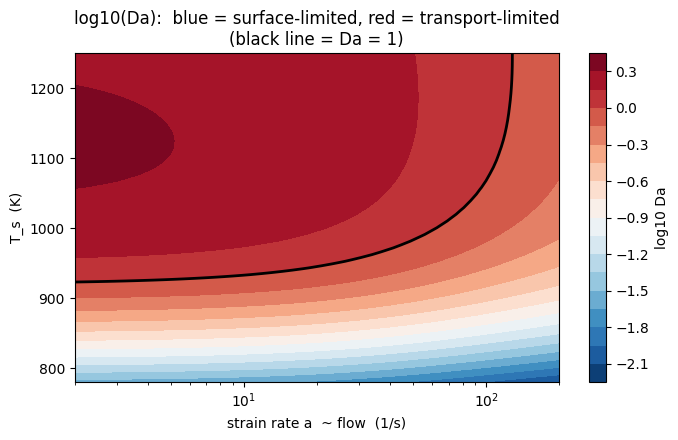

In [8]:
# jit + vmap so all grid points trace once and run in milliseconds
@jax.jit
def Da_point(T_s, a_strain):
    th = dict(base); th['T_s']=T_s; th['a_strain']=a_strain
    p_s, km, c_inf, D = coupled_solve(th)
    _, R_ads, _ = surface_rate(p_s, T_s, th['P'])
    c_s = p_s/(R_u*T_s)
    return (R_ads/c_s)/km                      # Damkohler

Ts = jnp.linspace(780., 1250., 50)
av = jnp.geomspace(2., 200., 50)
TT, AA = jnp.meshgrid(Ts, av, indexing='ij')
Da = np.array(jax.vmap(jax.vmap(Da_point))(TT, AA))

fig, ax = plt.subplots(figsize=(7,4.5))
cs = ax.contourf(np.array(av), np.array(Ts), np.log10(Da), levels=20, cmap="RdBu_r")
ax.contour(np.array(av), np.array(Ts), Da, levels=[1.0], colors="k", linewidths=2)
ax.set_xscale("log"); ax.set_xlabel("strain rate a  ~ flow  (1/s)")
ax.set_ylabel("T_s  (K)")
ax.set_title("log10(Da):  blue = surface-limited, red = transport-limited\n(black line = Da = 1)")
fig.colorbar(cs, label="log10 Da"); plt.tight_layout(); plt.show()

## Step 5 — Differentiability: free sensitivities $\partial G/\partial\theta$

Because the whole backbone is `jax`, one call to `jax.grad` gives **exact** process sensitivities — no finite differencing of ACE+, no surrogate needed for the gradient. These are precisely the gradients a gradient-based optimizer (or an adjoint over a Tier-2 field) will consume. We then **validate against finite differences** so you trust them.

In [9]:
def G_of(T_s, p_SiH4, a_strain):
    th = dict(base); th['T_s']=T_s; th['p_SiH4']=p_SiH4; th['a_strain']=a_strain
    return growth_rate(th)

T0, p0, a0 = 900.0, Pa(20.0), 10.0
gT = float(grad(G_of,0)(T0,p0,a0))
gp = float(grad(G_of,1)(T0,p0,a0))
ga = float(grad(G_of,2)(T0,p0,a0))

def fd(f,x,h): return (f(x+h)-f(x-h))/(2*h)
fdT = float(fd(lambda x:G_of(x,p0,a0), T0, 1e-2))
fdp = float(fd(lambda x:G_of(T0,x,a0), p0, p0*1e-5))
fda = float(fd(lambda x:G_of(T0,p0,x), a0, 1e-4))

print("sensitivity        jax.grad        finite-diff      match")
print(f"dG/dT_s (m/s/K)   {gT: .4e}    {fdT: .4e}   {np.isclose(gT,fdT,rtol=1e-4)}")
print(f"dG/dp   (m/s/Pa)  {gp: .4e}    {fdp: .4e}   {np.isclose(gp,fdp,rtol=1e-4)}")
print(f"dG/da   (m/s/(1/s)){ga: .4e}    {fda: .4e}   {np.isclose(ga,fda,rtol=1e-4)}")

sensitivity        jax.grad        finite-diff      match
dG/dT_s (m/s/K)    1.3363e-11     1.3363e-11   True
dG/dp   (m/s/Pa)   2.6171e-10     2.6171e-10   True
dG/da   (m/s/(1/s)) 3.2100e-12     3.2100e-12   True


**Reading the sensitivities.** The sign and magnitude tell you *which knob moves growth here*: near the crossover, $\partial G/\partial p>0$ and $\partial G/\partial a>0$ (more precursor and more flow both help, because transport is partly limiting), while $\partial G/\partial T_s$ is small (you're past the steep H-desorption ramp). Deep in the surface-limited corner the picture flips: $\partial G/\partial T_s$ dominates and $\partial G/\partial a\to0$. This is the optimizer's compass.

### Step 5.4 — General mechanisms (when there's no closed form)
For a multi-species surface mechanism the steady coverages solve $\mathbf{F}(\boldsymbol\theta;p,T)=\mathbf 0$ with no closed form. Keep differentiability via the **implicit function theorem** — either a Newton-in-`fori_loop` as above, or, more ergonomically, `optimistix`:

```python
import optimistix as optx
solver = optx.Newton(rtol=1e-10, atol=1e-12)
def F(theta_cov, args):           # residual vector dot{s}_j = 0, plus site closure
    p_s, T_s, P = args
    return site_balance_residuals(theta_cov, p_s, T_s, P)
sol = optx.root_find(F, solver, theta_guess, args=(p_s,T_s,P))
theta_cov = sol.value            # gradients flow through automatically (IFT)
```

For a *non-differentiable* but physically rich mechanism, define it in **Cantera** (`ct.Interface`, `.advance_coverages_to_steady_state()`), validate the toy model against it, and keep the JAX version for gradients. That Cantera cross-check is a good Tier-0 milestone before Tier 1.

## Step 6 — Package the backbone as a reusable module

The plan is: *notebook now (understand), one project later (run)*. Export the validated functions into `tier0_backbone.py` so Tier 1 imports it as the low-fidelity model `f_LF = growth_rate(theta)` instead of copy-pasting. The next cell writes that file.

In [10]:
module = '''\
\"\"\"tier0_backbone.py  -- differentiable two-resistance backbone for RP-CVD Si epitaxy.
Import: from tier0_backbone import growth_rate, diagnostics, PARAMS
This is the low-fidelity model f_LF that Tier 1 calibrates against CFD-ACE+.
\"\"\"
import jax, jax.numpy as jnp
from jax import grad
jax.config.update("jax_enable_x64", True)

R_u=8.314462618; k_B=1.380649e-23; N_A=6.02214076e23; eV=1.602176634e-19
M_SiH4=32.117e-3; m_SiH4=M_SiH4/N_A; M_Si=28.0855e-3; rho_Si=2329.0
Omega_Si=M_Si/rho_Si; Gamma=6.78e18/N_A

PARAMS=dict(s0=1.0e-2, Ea_ads=0.0*eV, nu_des=1.0e13, Ea_des=2.0*eV, beta=2.0)

def k_ads_eff(T,P): return P["s0"]*jnp.exp(-P["Ea_ads"]/(k_B*T))/(jnp.sqrt(2*jnp.pi*m_SiH4*k_B*T)*N_A)
def k_des_eff(T,P): return P["nu_des"]*Gamma*jnp.exp(-P["Ea_des"]/(k_B*T))
def theta_H_steady(p_s,T_s,P):
    r=jnp.sqrt(P["beta"]*k_ads_eff(T_s,P)*p_s/k_des_eff(T_s,P)); return r/(1+r)
def surface_rate(p_s,T_s,P):
    thH=theta_H_steady(p_s,T_s,P); R=k_ads_eff(T_s,P)*p_s*(1-thH)**2
    return Omega_Si*R, R, thH
def diffusivity(T,p_tot,D_ref=6.0e-5,T_ref=300.0,p_ref=101325.0):
    return D_ref*(T/T_ref)**1.75*(p_ref/p_tot)
def k_m_stagnation(a,D,L):
    bl=jnp.sqrt(jnp.pi*D/(2*a)); return D/(bl*jax.scipy.special.erf(L*jnp.sqrt(a/(2*D))))
def coupled_solve(th):
    T_s=th["T_s"]; D=diffusivity(T_s,th["p_tot"]); km=k_m_stagnation(th["a_strain"],D,th["L"])
    c_inf=th["p_SiH4"]/(R_u*T_s)
    def resid(c):
        _,R,_=surface_rate(c*R_u*T_s,T_s,th["P"]); return km*(c_inf-c)-R
    def body(i,c): return c-resid(c)/grad(resid)(c)
    c=jax.lax.fori_loop(0,60,body,0.5*c_inf); return c*R_u*T_s,km,c_inf,D
def growth_rate(th):
    p_s,km,c_inf,D=coupled_solve(th); return surface_rate(p_s,th["T_s"],th["P"])[0]
def diagnostics(th):
    p_s,km,c_inf,D=coupled_solve(th); G,R,thH=surface_rate(p_s,th["T_s"],th["P"])
    c_s=p_s/(R_u*th["T_s"]); Da=float((R/c_s)/km)
    return dict(G_nmmin=float(G)*1e9*60, theta_H=float(thH), Da=Da,
                depletion=float(1-c_s/c_inf), k_m=float(km))
'''
with open("tier0_backbone.py","w") as f: f.write(module)
print("wrote tier0_backbone.py")

# verify the exported module reproduces the notebook result
import importlib, tier0_backbone as tb; importlib.reload(tb)
th = dict(T_s=900.0, p_tot=Pa(10_000.), p_SiH4=Pa(20.0), a_strain=10.0, L=0.05, P=tb.PARAMS)
print("module growth_rate:", float(tb.growth_rate(th))*1e9*60, "nm/min")

wrote tier0_backbone.py
module growth_rate: 70.0160373943054 nm/min


## Step 7 — What you have, and the hook into Tier 1

**You now have, with zero ACE+ runs and zero GPU:**
- a validated steady surface map $\mathcal{R}$ that reproduces the Arrhenius rollover and the $p$-dependence flip;
- a closed-form, RP-aware mass-transfer coefficient $k_m$ (cross-checked against a BVP);
- a coupled, **differentiable** backbone $G(\theta)$ with machine-precision gradients and a $\mathrm{Da}$ regime map;
- the whole thing packaged as `tier0_backbone.py`.

**The Tier 1 hook.** Treat `growth_rate(theta)` as the low-fidelity model and fuse it with a handful of ACE+ runs via a multi-fidelity GP:
$$f_{\mathrm{HF}}(\theta)=\rho\,f_{\mathrm{LF}}(\theta)+\delta(\theta),\qquad \delta\sim\mathcal{GP}.$$
The GP only learns the small discrepancy $\delta$ and, in the same step, calibrates the placeholders in `PARAMS` (and the $k_m$ prefactor) against ACE+ — turning surrogate-fitting into physical parameter estimation. That is the next notebook.

**Suggested Tier-0 milestones to close out before Tier 1:**
1. swap the illustrative `PARAMS` for literature/DFT values (your H$_2$-desorption barrier from the carbon-project DFT stack if you want first-principles);
2. add a **DCS** variant ($\mathrm{HCl}$/$\mathrm{Cl}$ site-blocking, $\mathrm{HCl}$-desorption-limited at low $T$) — same site-balance machinery, one more surface species;
3. reproduce one published $G(T)$ curve to within a constant factor (then that factor is literally the first thing Tier 1 calibrates).